In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

In [5]:
Cadv = data_Cadv.Ah0.interp(time=data.time)
Cadv_int_ = data_Cadv.Ah0.integrate("time",datetime_unit="s")

In [6]:
from scipy import integrate

dt = (data.time.data-data.time[0].data).astype('int')*1e-9
Cadv_int = integrate.cumulative_trapezoid(Cadv.data, dt, axis=0, initial=0)

In [7]:
Cadv_int_.data - Cadv_int[-1,:,:]

array([[ 1.03397577e-24, -2.06795153e-25, -8.27180613e-25, ...,
         2.06795153e-25,  2.06795153e-25,  0.00000000e+00],
       [ 3.30872245e-24, -1.65436123e-24,  0.00000000e+00, ...,
        -8.27180613e-25, -8.27180613e-25, -8.27180613e-25],
       [ 3.30872245e-24, -6.61744490e-24,  3.30872245e-24, ...,
        -3.30872245e-24,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 3.33066907e-16,  3.33066907e-16,  2.22044605e-16, ...,
        -8.88178420e-16, -1.11022302e-16,  1.11022302e-16],
       [ 5.55111512e-16, -2.22044605e-16, -3.33066907e-16, ...,
        -6.66133815e-16,  6.66133815e-16,  1.22124533e-15],
       [-2.22044605e-16,  5.55111512e-16,  2.22044605e-16, ...,
        -1.11022302e-16, -2.22044605e-16,  1.11022302e-16]],
      shape=(1814, 1314))

# Island center & Shoaling depth

In [8]:
lambdaM2=70.1e3
l_sponge = 20e3
slope = 0.05
D0 = 600
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2
He = 313.1
width_he2 = 26000
width_top = width_he2 - 2*(He/2)/slope

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [9]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

In [10]:
x_top = x_c+width_top/2
x_bottom = x_top + D0/slope
x_shoal = x_top + depth_shoal/slope

# Scale time

In [11]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# plot time-area integrated energy terms

In [12]:
data_c = xr.open_dataset('../results_intermediate/dis_theta_c.nc')
dis_c = data_c.dis_c.data
theta_c = data_c.theta_c.data

In [13]:
dis_top = np.mean(dis_c[np.where((data_.depth>=depth_top+.1) & (data_.depth.data<=depth_top+2))])
dis_shoal = np.mean(dis_c[np.where((data_.depth>=depth_shoal-1) & (data_.depth.data<=depth_shoal+1))])
dis_bottom = np.mean(dis_c[np.where((data_.depth>=depth_bottom-1) & (data_.depth.data<depth_bottom))])
quadrants_info = {
    "r_quad": np.array([dis_top, dis_shoal,dis_bottom]),
    "quadrants": ['east', 'north', 'west', 'south'],
    "theta_edge":np.array([-45, 45, 135, -135]),
    "theta_quad": [[-45, 45], [45, 135], [135, -135], [-135, -45]], 
    "grid_number": 500,
            }

In [14]:
# mask out data outside of the inner ring
mask_ring_inner = (dis_c>=quadrants_info["r_quad"][0]) & (dis_c<quadrants_info["r_quad"][1])
mask_ring_inner_east = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_inner_north = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_inner_west = mask_ring_inner & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_inner_south = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# mask out data outside of the outer ring
mask_ring_outer = (dis_c>=quadrants_info["r_quad"][1]) & (dis_c<quadrants_info["r_quad"][-1])
mask_ring_outer_east = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_outer_north = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_outer_west = mask_ring_outer & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_outer_south = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

In [15]:
mask_ring = mask_ring_inner + mask_ring_outer
mask_ring_east = mask_ring_inner_east + mask_ring_outer_east

In [16]:
var = data_.C_int.copy() + Cadv_int
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
C_int = var_.integrate('y')

var = data.dissip_prime.copy() - Cadv_int
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dissip_prime_int = var_.integrate('y')

var = data.dissip0.copy() - Cadv_int
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dissip0_int = var_.integrate('y')

var = data_.dEp_prime.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dEp_prime_int = var_.integrate('y')

var = data_.dEk_prime.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dEk_prime_int = var_.integrate('y')

In [17]:
var = data_.dEp0.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dEp0_int = var_.integrate('y')

var = data_.dEk0.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dEk0_int = var_.integrate('y')

In [18]:
var = data_.D_prime.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
D_prime_int = var_.integrate('y')

var = data_.D0.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
D0_int = var_.integrate('y')

In [19]:
data_["ones"]=(['x', 'y'],  np.ones(data_.depth.shape))
var = data_.ones.copy()
var.data[~mask_ring] = 0
var_ = var.integrate('x')
area = var_.integrate('y')

In [20]:
# idx_x = np.where((data.x.data>=x_top) & (data.x.data<=x_bottom))[0]
# idx_y = np.where(np.abs(data.y-y_c)<dis_bottom)[0]

In [21]:
# var = data_.C_int[:,idx_x,idx_y].copy() + Cadv_int[:,idx_x,idx_y]
# var_ = var.integrate('x')
# C_int = var_.integrate('y')

# var = data.dissip_prime[:,idx_x,idx_y].copy() - Cadv_int[:,idx_x,idx_y]
# var_ = var.integrate('x')
# dissip_prime_int = var_.integrate('y')

# var = data.dissip0[:,idx_x,idx_y].copy() + Cadv_int[:,idx_x,idx_y]
# var_ = var.integrate('x')
# dissip0_int = var_.integrate('y')

# var = data_.dEp_prime[:,idx_x,idx_y].copy()
# var_ = var.integrate('x')
# dEp_prime_int = var_.integrate('y')

# var = data_.dEk_prime[:,idx_x,idx_y].copy()
# var_ = var.integrate('x')
# dEk_prime_int = var_.integrate('y')

In [22]:
# var = data_.D_prime[:,idx_x,idx_y].copy()
# var_ = var.integrate('x')
# D_prime_int = var_.integrate('y')

# var = data_.D0[:,idx_x,idx_y].copy()
# var_ = var.integrate('x')
# D0_int = var_.integrate('y')

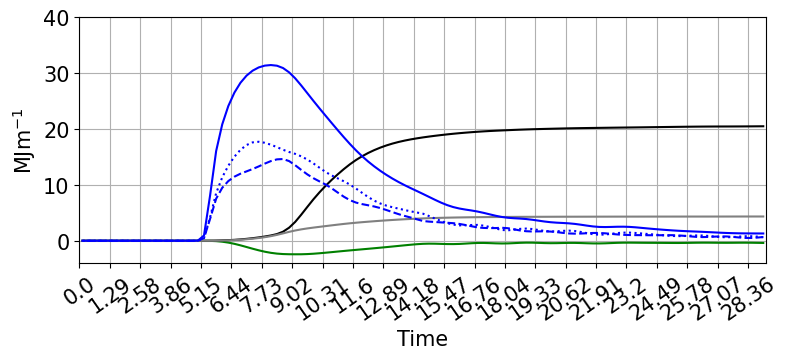

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3.7))

ax.plot(np.arange(len(data.time))[::-2], C_int[::-2]/(dis_bottom*2)*1e-6, c='g', label=r"$\overline{\int\int \langle C'\rangle dtdx}$")
# ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/(dis_bottom*2)*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), dissip0_int/(dis_bottom*2)*1e-6, c='k',ls='--', label=r"$\overline{\int\int\langle \epsilon_0\rangle dtdy}$")
# ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/(dis_bottom*2)*1e-6, c='gray', label=r"$\overline{\int\int\langle  D'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), D0_int/(dis_bottom*2)*1e-6, c='gray',ls='--', label=r"$\overline{\int\int\langle  D_0\rangle dtdy}$")
ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/(dis_bottom*2)*1e-6+dissip0_int/(dis_bottom*2)*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon\rangle dtdx}$")
ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/(dis_bottom*2)*1e-6+D0_int/(dis_bottom*2)*1e-6, c='gray', label=r"$\overline{\int\int\langle  D\rangle dtdx}$")

ax.plot(np.arange(len(data.time))[::-2], dEp_prime_int[::-2]/(dis_bottom*2)*1e-6, c='b',ls=':', label=r"$\overline{\int\langle  E_p' \rangle dx}$")
ax.plot(np.arange(len(data.time))[::-2], dEk_prime_int[::-2]/(dis_bottom*2)*1e-6, c='b',ls='--', label=r"$\overline{\int\langle  E_k' \rangle dx}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp_prime_int[::-2]+dEk_prime_int[::-2])/(dis_bottom*2)*1e-6, c='b', label=r"$\overline{\int \langle E_k'\rangle +\langle E_p'\rangle  dx}$")
# ax.legend(loc='upper right', ncol=3)
ax.set_ylabel(r'MJm$^{-1}$', fontsize=15)
ax.set_ylim([-4,40])
ax.set_xlim([0,len(data.time)])
ax.set_xlabel('Time', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='x', rotation = 35)
ax.set_title('')
ax.set_xticks(np.arange(0,len(data.time)+1,10))
ax.set_xticklabels(np.round(t_nondim[np.arange(0,len(data.time)+1,10)],2))

plt.rcParams["font.family"] = "Times New Roman"  
plt.tight_layout()

ax.grid()

plt.savefig(outfilepath+ f"energy_int_yaverage_summer_nof_3d.png", transparent = True, dpi=300)

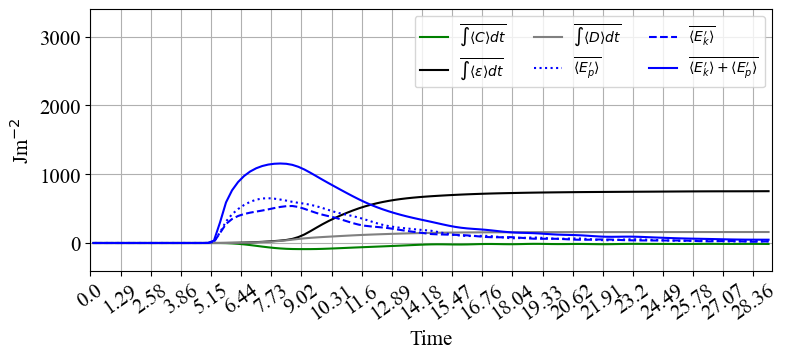

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3.7))

ax.plot(np.arange(len(data.time))[::-2], C_int[::-2]/area, c='g', label=r"$\overline{\int\langle C\rangle dt}$")
# ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/data.y[-1]*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), dissip0_int/data.y[-1]*1e-6, c='k',ls='--', label=r"$\overline{\int\int\langle \epsilon_0\rangle dtdy}$")
# ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/data.y[-1]*1e-6, c='gray', label=r"$\overline{\int\int\langle  D'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), D0_int/data.y[-1]*1e-6, c='gray',ls='--', label=r"$\overline{\int\int\langle  D_0\rangle dtdy}$")
ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/area+dissip0_int/area, c='k', label=r"$\overline{\int\langle \epsilon\rangle dt}$")
ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/area+D0_int/area, c='gray', label=r"$\overline{\int\langle  D\rangle dt}$")

ax.plot(np.arange(len(data.time))[::-2], dEp_prime_int[::-2]/area, c='b',ls=':', label=r"$\overline{\langle  E_p' \rangle}$")
ax.plot(np.arange(len(data.time))[::-2], dEk_prime_int[::-2]/area, c='b',ls='--', label=r"$\overline{\langle  E_k' \rangle}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp_prime_int[::-2]+dEk_prime_int[::-2])/area, c='b', label=r"$\overline{\langle E_k'\rangle +\langle E_p'\rangle}$")
ax.legend(loc='upper right', ncol=3)
ax.set_ylabel(r'Jm$^{-2}$', fontsize=15)
ax.set_ylim([-400,3400])
ax.set_xlim([0,len(data.time)])
ax.set_xlabel('Time', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='x', rotation = 35)
ax.set_title('')
ax.set_xticks(np.arange(0,len(data.time)+1,10))
ax.set_xticklabels(np.round(t_nondim[np.arange(0,len(data.time)+1,10)],2))

plt.rcParams["font.family"] = "Times New Roman"  
plt.tight_layout()

ax.grid()

plt.savefig(outfilepath+ f"energy_int_areaaverage_summer_nof_3d.png", transparent = True, dpi=300)

In [25]:
var = data_.C_int.copy() + Cadv_int
var.data[:,~mask_ring_east] = 0
var_ = var.integrate('x')
C_int = var_.integrate('y')

var = data.dissip_prime.copy() - Cadv_int
var.data[:,~mask_ring_east] = 0
var_ = var.integrate('x')
dissip_prime_int = var_.integrate('y')

var = data.dissip0.copy() - Cadv_int
var.data[:,~mask_ring_east] = 0
var_ = var.integrate('x')
dissip0_int = var_.integrate('y')

var = data_.dEp_prime.copy()
var.data[:,~mask_ring_east] = 0
var_ = var.integrate('x')
dEp_prime_int = var_.integrate('y')

var = data_.dEk_prime.copy()
var.data[:,~mask_ring_east] = 0
var_ = var.integrate('x')
dEk_prime_int = var_.integrate('y')

In [26]:
var = data_.D_prime.copy()
var.data[:,~mask_ring_east] = 0
var_ = var.integrate('x')
D_prime_int = var_.integrate('y')

var = data_.D0.copy()
var.data[:,~mask_ring_east] = 0
var_ = var.integrate('x')
D0_int = var_.integrate('y')

In [27]:
data_["ones"]=(['x', 'y'],  np.ones(data_.depth.shape))
var = data_.ones.copy()
var.data[~mask_ring_east] = 0
var_ = var.integrate('x')
area = var_.integrate('y')

In [30]:
var = data_.dEp0.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dEp0_int = var_.integrate('y')

var = data_.dEk0.copy()
var.data[:,~mask_ring] = 0
var_ = var.integrate('x')
dEk0_int = var_.integrate('y')

In [28]:
area

<xarray.DataArray 'ones' ()> Size: 8B
array(2.97212508e+08)

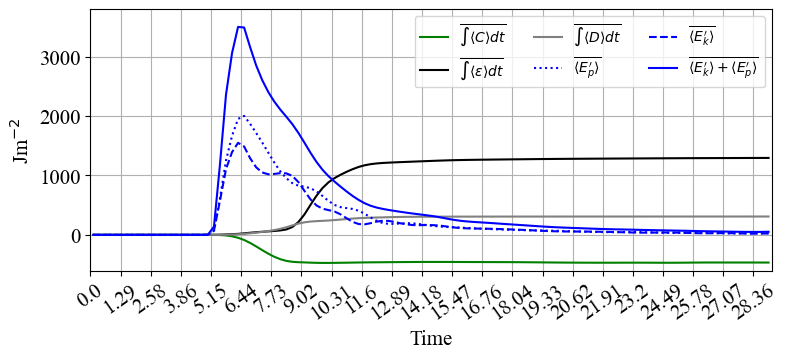

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3.7))

ax.plot(np.arange(len(data.time))[::-2], C_int[::-2]/area, c='g', label=r"$\overline{\int\langle C\rangle dt}$")
# ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/data.y[-1]*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), dissip0_int/data.y[-1]*1e-6, c='k',ls='--', label=r"$\overline{\int\int\langle \epsilon_0\rangle dtdy}$")
# ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/data.y[-1]*1e-6, c='gray', label=r"$\overline{\int\int\langle  D'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), D0_int/data.y[-1]*1e-6, c='gray',ls='--', label=r"$\overline{\int\int\langle  D_0\rangle dtdy}$")
ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/area+dissip0_int/area, c='k', label=r"$\overline{\int\langle \epsilon\rangle dt}$")
ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/area+D0_int/area, c='gray', label=r"$\overline{\int\langle  D\rangle dt}$")

ax.plot(np.arange(len(data.time))[::-2], dEp_prime_int[::-2]/area, c='b',ls=':', label=r"$\overline{\langle  E_p' \rangle}$")
ax.plot(np.arange(len(data.time))[::-2], dEk_prime_int[::-2]/area, c='b',ls='--', label=r"$\overline{\langle  E_k' \rangle}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp_prime_int[::-2]+dEk_prime_int[::-2])/area, c='b', label=r"$\overline{\langle E_k'\rangle +\langle E_p'\rangle}$")
ax.legend(loc='upper right', ncol=3)
ax.set_ylabel(r'Jm$^{-2}$', fontsize=15)
ax.set_ylim([-600,3800])
ax.set_xlim([0,len(data.time)])
ax.set_xlabel('Time', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='x', rotation = 35)
ax.set_title('')
ax.set_xticks(np.arange(0,len(data.time)+1,10))
ax.set_xticklabels(np.round(t_nondim[np.arange(0,len(data.time)+1,10)],2))

plt.rcParams["font.family"] = "Times New Roman"  
plt.tight_layout()

ax.grid()

plt.savefig(outfilepath+ f"energy_int_areaaverage_summer_nof_3d.png", transparent = True, dpi=300)

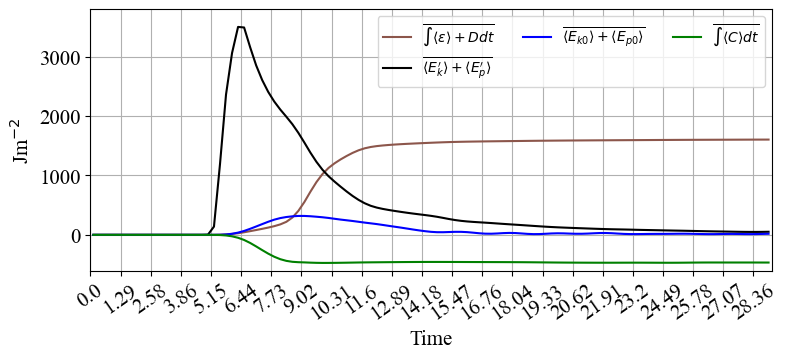

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3.7))

# ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/data.y[-1]*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), dissip0_int/data.y[-1]*1e-6, c='k',ls='--', label=r"$\overline{\int\int\langle \epsilon_0\rangle dtdy}$")
# ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/data.y[-1]*1e-6, c='gray', label=r"$\overline{\int\int\langle  D'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), D0_int/data.y[-1]*1e-6, c='gray',ls='--', label=r"$\overline{\int\int\langle  D_0\rangle dtdy}$")
ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/area+dissip0_int/area+D_prime_int[::-2]/area+D0_int/area, c='tab:brown', label=r"$\overline{\int\langle  \epsilon\rangle+D dt}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp_prime_int[::-2]+dEk_prime_int[::-2])/area, c='k', label=r"$\overline{\langle E_k'\rangle +\langle E_p'\rangle}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp0_int[::-2]+dEk0_int[::-2])/area, c='b', label=r"$\overline{\langle E_{k0}\rangle +\langle E_{p0}\rangle}$")
ax.plot(np.arange(len(data.time))[::-2], C_int[::-2]/area, c='g', label=r"$\overline{\int\langle C\rangle dt}$")

ax.legend(loc='upper right', ncol=3)
ax.set_ylabel(r'Jm$^{-2}$', fontsize=15)
ax.set_ylim([-600,3800])
ax.set_xlim([0,len(data.time)])
ax.set_xlabel('Time', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='x', rotation = 35)
ax.set_title('')
ax.set_xticks(np.arange(0,len(data.time)+1,10))
ax.set_xticklabels(np.round(t_nondim[np.arange(0,len(data.time)+1,10)],2))

plt.rcParams["font.family"] = "Times New Roman"  
plt.tight_layout()

ax.grid()

plt.savefig(outfilepath+ f"energy_int_areaaverage_summer_nof_3d.png", transparent = True, dpi=300)